In [16]:
import os
import re
import numpy as np
import pandas as pd

# =========================================================
# 1. 基本設定
# =========================================================
base_path = r"C:\AR5_統計降尺度_日資料_臺北市_平均溫"

# 蟑螂 degree-day 參數
T_BASE = 15.9
K = 650

# 分析年份（AR5: historical 到 2005，RCP 從 2006 開始）
HIST_START = 2004
HIST_END   = 2005
FUT_START  = 2006
FUT_END    = 2036

SCENARIOS = ["rcp26", "rcp45", "rcp60", "rcp85"]

# 360-day 或你不想納入的模式
EXCLUDE_MODELS = ["HadGEM2-ES", "HadGEM2-CC", "HadGEM2-AO"]

# 目標位置（你之前用過的大學里附近）
poi_lat = 25.0190099143756
poi_lon = 121.53137177116402


# =========================================================
# 2. 檔名解析
# =========================================================
def parse_filename(file_name: str):
    """
    支援：
    AR5_統計降尺度_日資料_臺北市_平均溫_historical_ACCESS1-0_1962
    AR5_統計降尺度_日資料_臺北市_平均溫_historical_ACCESS1-0_1962.csv
    """
    pattern = (
        r"^AR5_統計降尺度_日資料_"
        r"(?P<region>.+?)_"
        r"(?P<variable>最高溫|平均溫|最低溫|降雨量)_"
        r"(?P<scenario>historical|rcp26|rcp45|rcp60|rcp85)_"
        r"(?P<model>.+?)_"
        r"(?P<year>\d{4})"
        r"(?:\.csv)?$"
    )

    m = re.match(pattern, file_name)
    if not m:
        return None

    info = m.groupdict()
    info["year"] = int(info["year"])
    return info


# =========================================================
# 3. 掃描所有檔案
# =========================================================
def scan_all_files(base_path):
    rows = []

    for fn in os.listdir(base_path):
        full_path = os.path.join(base_path, fn)

        if not os.path.isfile(full_path):
            continue

        info = parse_filename(fn)
        if info is None:
            continue

        info["file_name"] = fn
        info["file_path"] = full_path
        rows.append(info)

    meta_df = pd.DataFrame(rows)

    if meta_df.empty:
        raise ValueError("掃描不到符合格式的檔案，請確認資料夾與檔名格式。")

    return meta_df


# =========================================================
# 4. 取得日期欄位
# =========================================================
def get_date_columns(df):
    """
    找出像 20040101 這種每日欄位
    """
    date_cols = [c for c in df.columns if re.fullmatch(r"\d{8}", str(c))]
    date_cols = sorted(date_cols)
    return date_cols


# =========================================================
# 5. 取最近格點的一年每日序列
# =========================================================
def extract_nearest_grid_daily_series(csv_path, poi_lat, poi_lon):
    df = pd.read_csv(csv_path)

    # 移除像 Unnamed: 367 這類多餘欄位
    df = df.loc[:, ~df.columns.str.contains(r"^Unnamed")].copy()

    # 經緯度欄位
    if "LAT" not in df.columns or "LON" not in df.columns:
        raise ValueError(f"{os.path.basename(csv_path)} 找不到 LAT/LON 欄位")

    # 找每日欄位
    date_cols = get_date_columns(df)
    if len(date_cols) == 0:
        raise ValueError(f"{os.path.basename(csv_path)} 找不到 YYYYMMDD 日期欄位")

    # 找最近格點
    df["dist"] = np.sqrt((df["LAT"] - poi_lat)**2 + (df["LON"] - poi_lon)**2)
    nearest_idx = df["dist"].idxmin()
    nearest_row = df.loc[nearest_idx]

    # 取出該格點一年每日值
    daily_values = pd.to_numeric(nearest_row[date_cols], errors="coerce").values.astype(float)

    return daily_values, date_cols, nearest_row["LAT"], nearest_row["LON"]


# =========================================================
# 6. 單一年份 -> GDD 與世代數
# =========================================================
def calculate_generations_from_daily_values(daily_values, t_base=15.9, K=650):
    daily_values = np.asarray(daily_values, dtype=float)

    gdd_daily = np.maximum(daily_values - t_base, 0)
    total_gdd = np.nansum(gdd_daily)

    return {
        "total_gdd": float(total_gdd),
        "generations_int": int(total_gdd // K),
        "generations_float": float(total_gdd / K),
        "n_days": int(np.sum(~np.isnan(daily_values)))
    }


# =========================================================
# 7. 建立單一模式 × 單一 RCP 的完整年序列
#    historical: 2004-2005
#    future    : 2006-2036
# =========================================================
def build_model_scenario_series(meta_df, model, scenario, poi_lat, poi_lon):
    hist_df = meta_df[
        (meta_df["scenario"] == "historical") &
        (meta_df["model"] == model) &
        (meta_df["year"].between(HIST_START, HIST_END))
    ].copy()

    fut_df = meta_df[
        (meta_df["scenario"] == scenario) &
        (meta_df["model"] == model) &
        (meta_df["year"].between(FUT_START, FUT_END))
    ].copy()

    needed_hist_years = set(range(HIST_START, HIST_END + 1))
    needed_fut_years = set(range(FUT_START, FUT_END + 1))

    have_hist_years = set(hist_df["year"].tolist())
    have_fut_years = set(fut_df["year"].tolist())

    missing_hist = sorted(list(needed_hist_years - have_hist_years))
    missing_fut = sorted(list(needed_fut_years - have_fut_years))

    if missing_hist or missing_fut:
        return None, {
            "model": model,
            "scenario": scenario,
            "missing_hist": missing_hist,
            "missing_fut": missing_fut
        }

    merged = pd.concat([hist_df, fut_df], ignore_index=True).sort_values("year")

    rows = []

    for _, r in merged.iterrows():
        daily_values, date_cols, grid_lat, grid_lon = extract_nearest_grid_daily_series(
            r["file_path"], poi_lat, poi_lon
        )

        result = calculate_generations_from_daily_values(
            daily_values, t_base=T_BASE, K=K
        )

        rows.append({
            "year": r["year"],
            "model": model,
            "scenario": scenario,
            "source_scenario": r["scenario"],
            "total_gdd": result["total_gdd"],
            "generations_int": result["generations_int"],
            "generations_float": result["generations_float"],
            "n_days": result["n_days"],
            "n_date_cols": len(date_cols),
            "grid_lat": grid_lat,
            "grid_lon": grid_lon
        })

    out_df = pd.DataFrame(rows)
    return out_df, None


# =========================================================
# 8. 主程式：處理所有模式 × 所有 RCP
# =========================================================
def build_all_generation_series(base_path, poi_lat, poi_lon):
    meta_df = scan_all_files(base_path)

    # 只取臺北市 + 平均溫
    meta_df = meta_df[
        (meta_df["region"] == "臺北市") &
        (meta_df["variable"] == "平均溫")
    ].copy()

    # 排除模式
    meta_df = meta_df[~meta_df["model"].isin(EXCLUDE_MODELS)].copy()

    models = sorted(meta_df["model"].unique().tolist())

    all_results = []
    missing_logs = []

    for model in models:
        for scenario in SCENARIOS:
            df_one, miss_info = build_model_scenario_series(
                meta_df, model, scenario, poi_lat, poi_lon
            )

            if miss_info is not None:
                missing_logs.append(miss_info)
                continue

            all_results.append(df_one)

    if not all_results:
        raise ValueError("沒有成功組出任何完整的 model × scenario 序列。")

    result_df = pd.concat(all_results, ignore_index=True)
    missing_df = pd.DataFrame(missing_logs)

    return result_df, missing_df, meta_df


# =========================================================
# 9. 執行
# =========================================================
df_generations, df_missing, meta_df = build_all_generation_series(
    base_path=base_path,
    poi_lat=poi_lat,
    poi_lon=poi_lon
)
df_generations["dd_anomaly_5gen"] = df_generations["total_gdd"] - 5 * K

# 存檔
out_csv = os.path.join(base_path, "AR5_cockroach_generations_2004_2036.csv")
df_generations.to_csv(out_csv, index=False, encoding="utf-8-sig")

missing_csv = os.path.join(base_path, "AR5_cockroach_generations_missing_models.csv")
df_missing.to_csv(missing_csv, index=False, encoding="utf-8-sig")

print("完成")
print("世代數檔案：", out_csv)
print("缺年紀錄：", missing_csv)
print(df_generations.head())

完成
世代數檔案： C:\AR5_統計降尺度_日資料_臺北市_平均溫\AR5_cockroach_generations_2004_2036.csv
缺年紀錄： C:\AR5_統計降尺度_日資料_臺北市_平均溫\AR5_cockroach_generations_missing_models.csv
   year      model scenario source_scenario  total_gdd  generations_int  \
0  2004  ACCESS1-0    rcp45      historical  2968.2657                4   
1  2005  ACCESS1-0    rcp45      historical  2879.5955                4   
2  2006  ACCESS1-0    rcp45           rcp45  2789.2322                4   
3  2007  ACCESS1-0    rcp45           rcp45  2925.4799                4   
4  2008  ACCESS1-0    rcp45           rcp45  3097.8856                4   

   generations_float  n_days  n_date_cols  grid_lat  grid_lon  dd_anomaly_5gen  
0           4.566563     365          365      25.0    121.55        -281.7343  
1           4.430147     365          365      25.0    121.55        -370.4045  
2           4.291126     365          365      25.0    121.55        -460.7678  
3           4.500738     365          365      25.0    121.55        -324.

In [9]:
print(meta_df.head())
print(sorted(meta_df["scenario"].unique()))
print(meta_df["model"].nunique())
print(df_generations.head(10))
print(df_missing.head())

  region variable    scenario      model  year  \
0    臺北市      平均溫  historical  ACCESS1-0  1960   
1    臺北市      平均溫  historical  ACCESS1-0  1961   
2    臺北市      平均溫  historical  ACCESS1-0  1962   
3    臺北市      平均溫  historical  ACCESS1-0  1963   
4    臺北市      平均溫  historical  ACCESS1-0  1964   

                                           file_name  \
0  AR5_統計降尺度_日資料_臺北市_平均溫_historical_ACCESS1-0_196...   
1  AR5_統計降尺度_日資料_臺北市_平均溫_historical_ACCESS1-0_196...   
2  AR5_統計降尺度_日資料_臺北市_平均溫_historical_ACCESS1-0_196...   
3  AR5_統計降尺度_日資料_臺北市_平均溫_historical_ACCESS1-0_196...   
4  AR5_統計降尺度_日資料_臺北市_平均溫_historical_ACCESS1-0_196...   

                                           file_path  
0  C:\AR5_統計降尺度_日資料_臺北市_平均溫\AR5_統計降尺度_日資料_臺北市_平均溫...  
1  C:\AR5_統計降尺度_日資料_臺北市_平均溫\AR5_統計降尺度_日資料_臺北市_平均溫...  
2  C:\AR5_統計降尺度_日資料_臺北市_平均溫\AR5_統計降尺度_日資料_臺北市_平均溫...  
3  C:\AR5_統計降尺度_日資料_臺北市_平均溫\AR5_統計降尺度_日資料_臺北市_平均溫...  
4  C:\AR5_統計降尺度_日資料_臺北市_平均溫\AR5_統計降尺度_日資料_臺北市_平均溫...  
['historical', 'rcp26', 'rcp45',

In [10]:
complete_counts = (
    df_generations[["model", "scenario"]]
    .drop_duplicates()
    .groupby("scenario")
    .size()
    .reset_index(name="n_models")
)

print(complete_counts)

  scenario  n_models
0    rcp26        20
1    rcp45        27
2    rcp60        15
3    rcp85        30


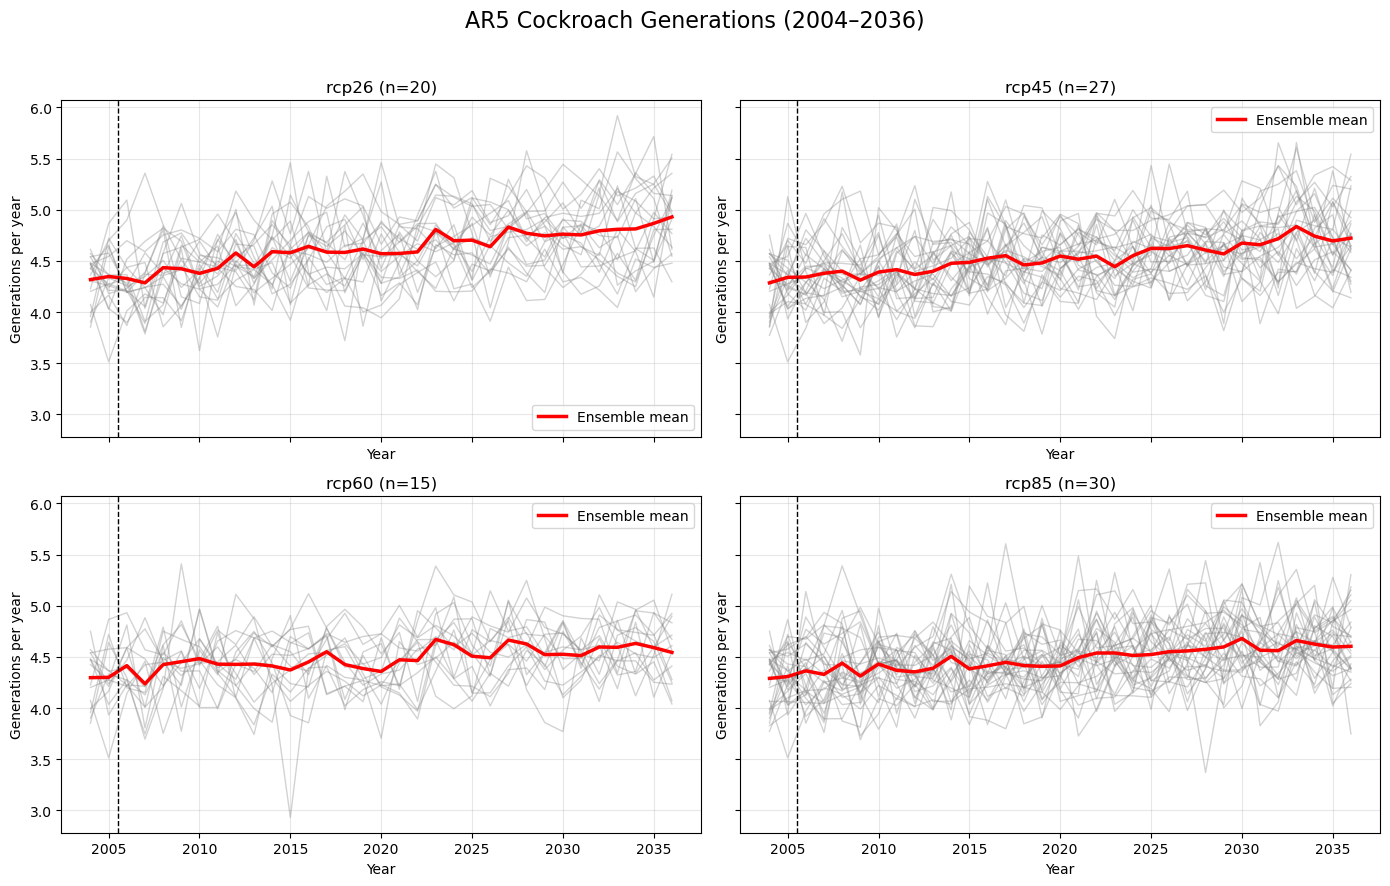

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
# 輸出資料夾
output_dir = Path(r"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue")#"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue"
output_dir.mkdir(parents=True, exist_ok=True)

# 確保年份排序
df_plot = df_generations.copy().sort_values(["scenario", "model", "year"])

scenarios = ["rcp26", "rcp45", "rcp60", "rcp85"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.flatten()

for ax, scen in zip(axes, scenarios):
    sub = df_plot[df_plot["scenario"] == scen].copy()
    models = sorted(sub["model"].unique())

    # 畫每個模式
    for model in models:
        msub = sub[sub["model"] == model].sort_values("year")
        ax.plot(
            msub["year"],
            msub["generations_float"],
            color="gray",
            alpha=0.35,
            linewidth=1
        )

    # 畫 ensemble mean
    mean_df = (
        sub.groupby("year", as_index=False)["generations_float"]
        .mean()
        .sort_values("year")
    )

    ax.plot(
        mean_df["year"],
        mean_df["generations_float"],
        color="red",
        linewidth=2.5,
        label="Ensemble mean"
    )

    # historical / future 分界
    ax.axvline(2005.5, color="black", linestyle="--", linewidth=1)

    ax.set_title(f"{scen} (n={len(models)})", fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("Generations per year")
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("AR5 Cockroach Generations (2004–2036)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
outpath = output_dir / f"AR5 Cockroach Generations (2004–2036).png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

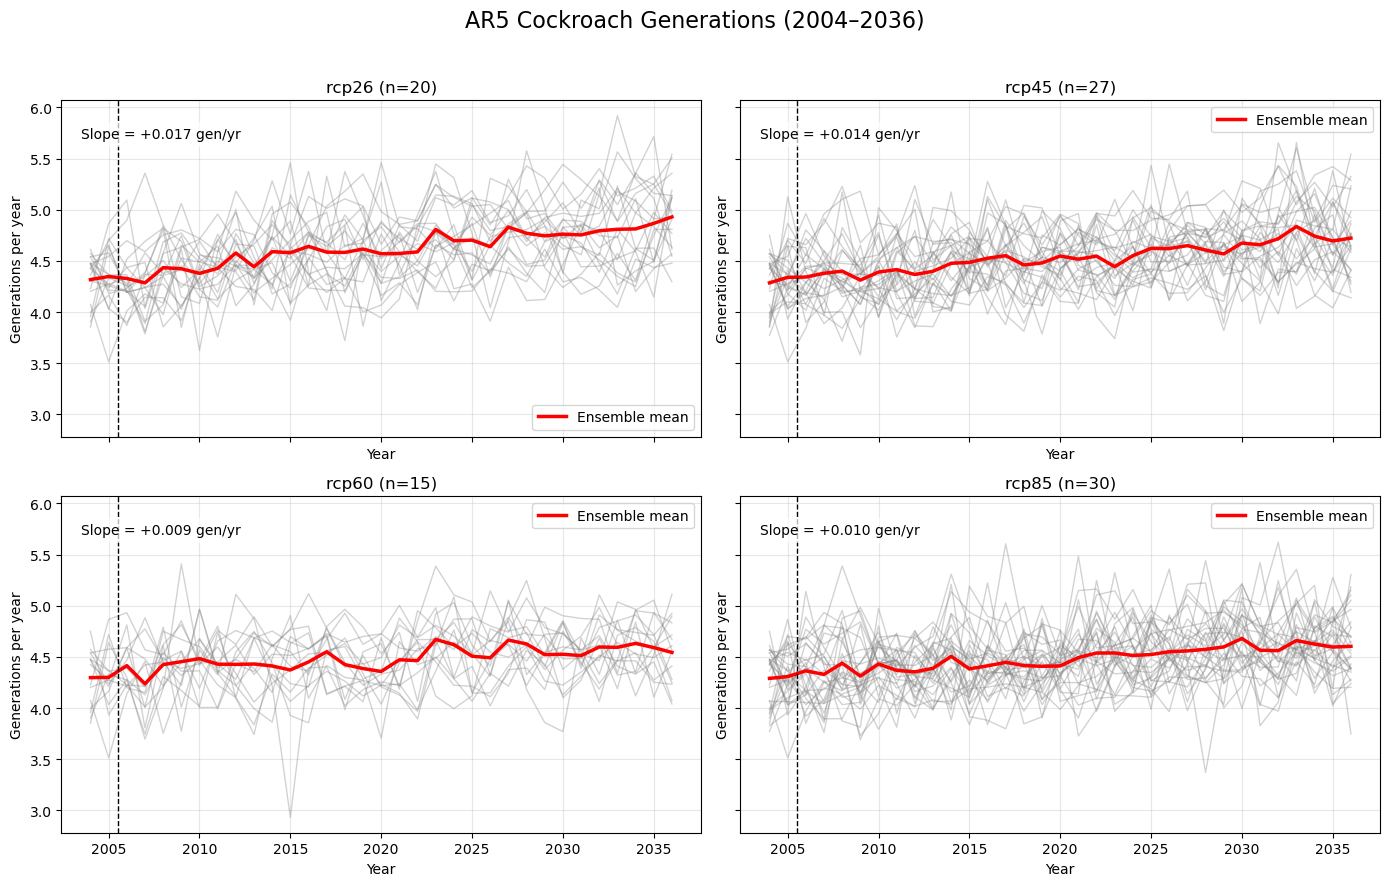

In [15]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = df_generations.copy().sort_values(["scenario", "model", "year"])
scenarios = ["rcp26", "rcp45", "rcp60", "rcp85"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.flatten()

for ax, scen in zip(axes, scenarios):
    sub = df_plot[df_plot["scenario"] == scen].copy()
    models = sorted(sub["model"].unique())

    # 各模式灰線
    for model in models:
        msub = sub[sub["model"] == model].sort_values("year")
        ax.plot(
            msub["year"],
            msub["generations_float"],
            color="gray",
            alpha=0.35,
            linewidth=1
        )

    # ensemble mean
    mean_df = (
        sub.groupby("year", as_index=False)["generations_float"]
        .mean()
        .sort_values("year")
    )

    ax.plot(
        mean_df["year"],
        mean_df["generations_float"],
        color="red",
        linewidth=2.5,
        label="Ensemble mean"
    )

    # 分界線
    ax.axvline(2005.5, color="black", linestyle="--", linewidth=1)

    # 斜率（不畫趨勢線，只顯示文字）
    x = mean_df["year"].values
    y = mean_df["generations_float"].values
    slope, intercept = np.polyfit(x, y, 1)

    # 放在圖內空白處
    ax.text(
        0.03, 0.92,
        f"Slope = {slope:+.3f} gen/yr",
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

    ax.set_title(f"{scen} (n={len(models)})", fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("Generations per year")
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("AR5 Cockroach Generations (2004–2036)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
outpath = output_dir / f"AR5 Cockroach Generations_1 (2004–2036).png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

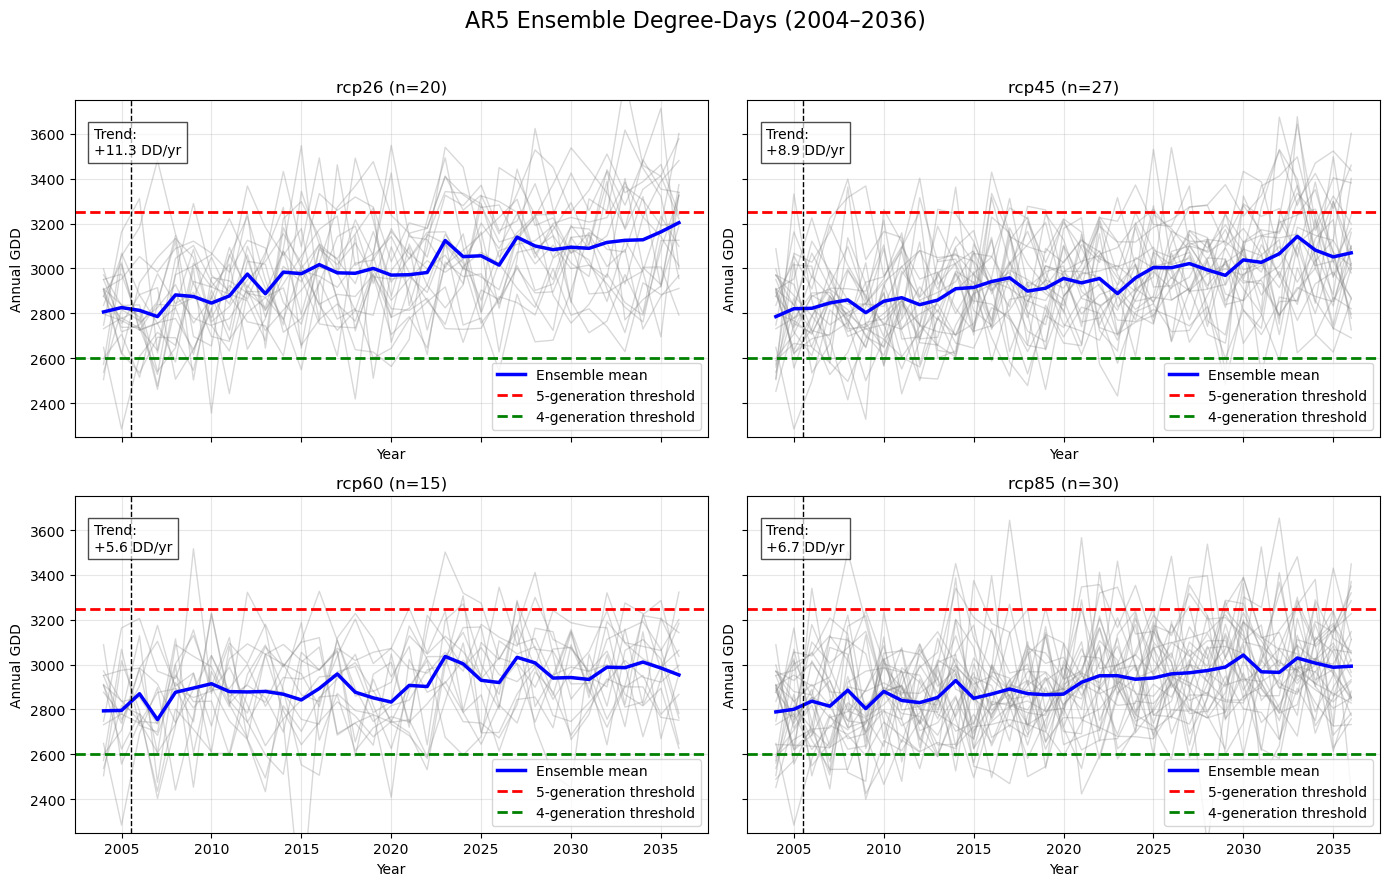

In [24]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = df_generations.copy().sort_values(["scenario", "model", "year"])
scenarios = ["rcp26", "rcp45", "rcp60", "rcp85"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.flatten()

for ax, scen in zip(axes, scenarios):
    sub = df_plot[df_plot["scenario"] == scen].copy()
    models = sorted(sub["model"].unique())

    # ===== 每個模式（灰線）=====
    for model in models:
        msub = sub[sub["model"] == model].sort_values("year")
        ax.plot(
            msub["year"],
            msub["total_gdd"],
            color="gray",
            alpha=0.3,
            linewidth=1
        )

    # ===== ensemble mean =====
    mean_df = (
        sub.groupby("year", as_index=False)["total_gdd"]
        .mean()
        .sort_values("year")
    )

    ax.plot(
        mean_df["year"],
        mean_df["total_gdd"],
        color="blue",
        linewidth=2.5,
        label="Ensemble mean"
    )
    ax.legend(loc="lower right")

    # ===== 門檻線 =====
    ax.axhline(5 * K, color="red", linestyle="--", linewidth=2, label="5-generation threshold")
    ax.axhline(4 * K, color="green", linestyle="--", linewidth=2, label="4-generation threshold")

    # ===== 分界線 =====
    ax.axvline(2005.5, color="black", linestyle="--", linewidth=1)

    # ===== 計算 trend（只顯示文字）=====
    x = mean_df["year"].values
    y = mean_df["total_gdd"].values
    slope, _ = np.polyfit(x, y, 1)

    ax.text(
        0.03, 0.92,
        f"Trend:\n{slope:+.1f} DD/yr",
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        bbox=dict(facecolor="white", alpha=0.7)
    )

    ax.set_title(f"{scen} (n={len(models)})", fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual GDD")
    ax.set_ylim([2250,3750])
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)
    #ax.legend()

plt.suptitle("AR5 Ensemble Degree-Days (2004–2036)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
outpath = output_dir / f"AR5 Cockroach Generations_dd (2004–2036).png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

In [29]:
df_generations["dd_anomaly_5gen"] = df_generations["total_gdd"] - 5 * K
df_generations["dd_anomaly_4gen"] = df_generations["total_gdd"] - 4 * K
df_generations["dd_centered"] = df_generations["total_gdd"] - 4.5 * K

C:\Users\user\AppData\Local\Temp\ipykernel_1744\1338432015.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


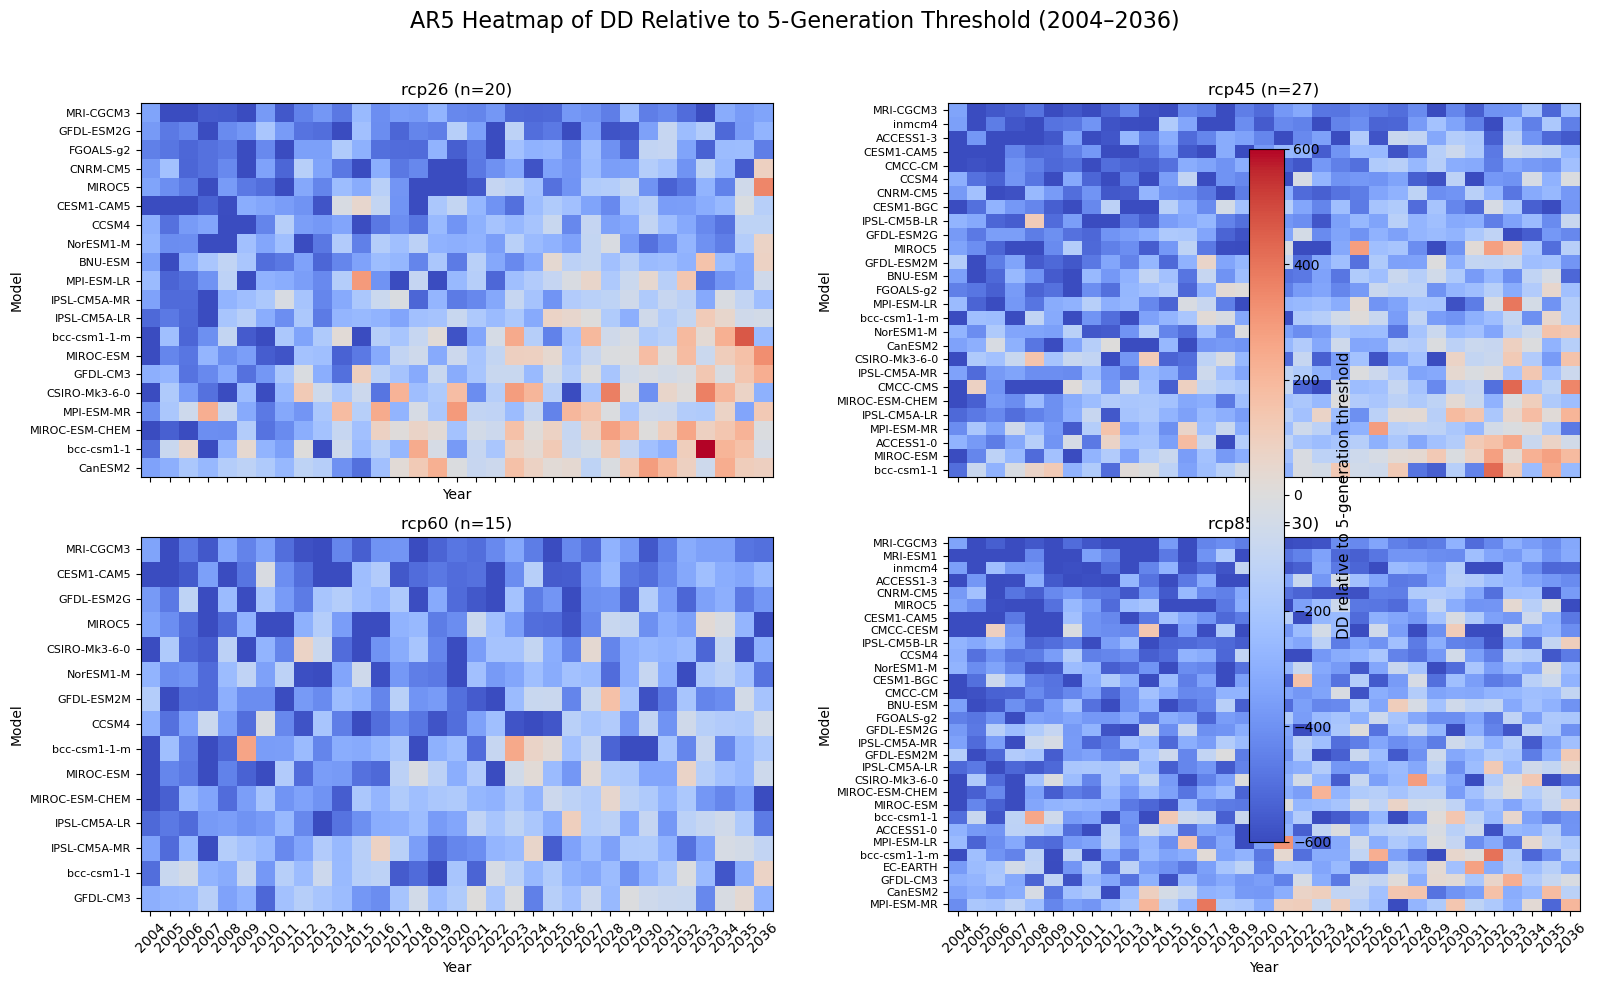

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_plot = df_generations.copy()

scenarios = ["rcp26", "rcp45", "rcp60", "rcp85"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=False)
axes = axes.flatten()

for ax, scen in zip(axes, scenarios):
    sub = df_plot[df_plot["scenario"] == scen].copy()

    # 依 2004–2036 平均值排序，讓 heatmap 更好讀
    model_order = (
        sub.groupby("model")["dd_anomaly_5gen"]
        .mean()
        .sort_values()
        .index
        .tolist()
    )

    heat_df = sub.pivot(index="model", columns="year", values="dd_anomaly_5gen")
    heat_df = heat_df.loc[model_order]

    im = ax.imshow(
        heat_df.values,
        aspect="auto",
        cmap="coolwarm",
        interpolation="nearest",
        vmin=-600,
        vmax=600
    )

    ax.set_title(f"{scen} (n={heat_df.shape[0]})", fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("Model")

    ax.set_xticks(np.arange(len(heat_df.columns)))
    ax.set_xticklabels(heat_df.columns, rotation=45)

    ax.set_yticks(np.arange(len(heat_df.index)))
    ax.set_yticklabels(heat_df.index, fontsize=8)

# 共用 colorbar
cbar = fig.colorbar(im, ax=axes, shrink=0.9, pad=0.02)
cbar.set_label("DD relative to 5-generation threshold", fontsize=11)

plt.suptitle("AR5 Heatmap of DD Relative to 5-Generation Threshold (2004–2036)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [27]:
def classify_dd(gdd, K=650):
    if gdd < 4*K:
        return 0   # <4代
    elif gdd < 5*K:
        return 1   # 4–5代
    else:
        return 2   # >=5代

df_generations["gen_class"] = df_generations["total_gdd"].apply(classify_dd)

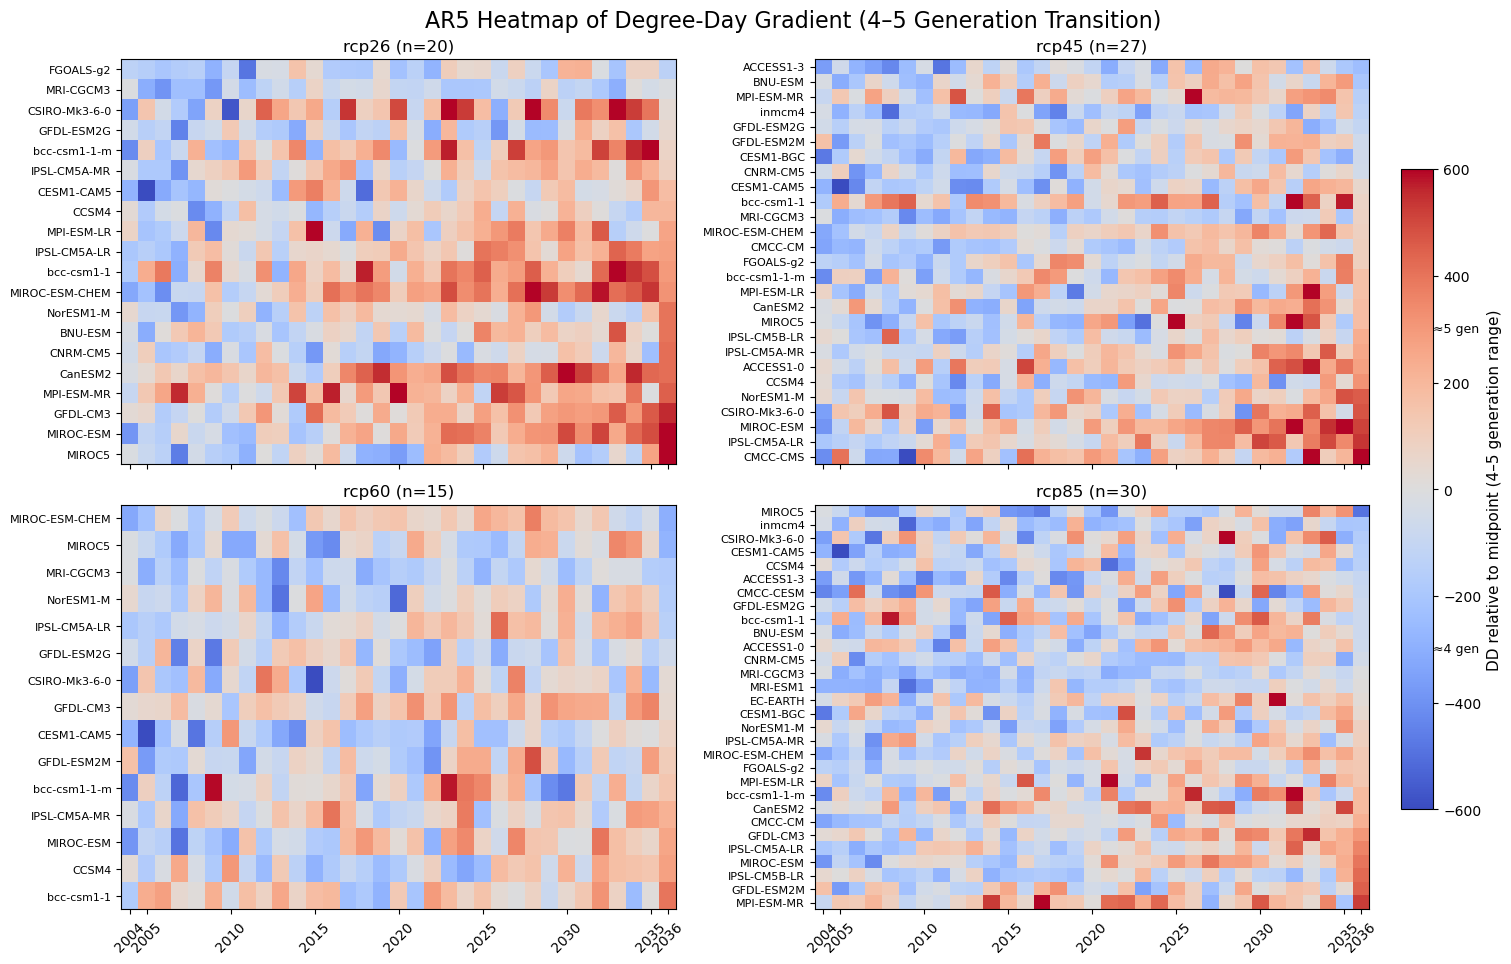

In [34]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = df_generations.copy()
scenarios = ["rcp26", "rcp45", "rcp60", "rcp85"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=False)
axes = axes.flatten()

vmin = -600
vmax = 600

for ax, scen in zip(axes, scenarios):
    sub = df_plot[df_plot["scenario"] == scen].copy()

    model_order = (
        sub[sub["year"] == 2036]
        .sort_values("total_gdd")["model"]
        .tolist()
    )

    heat_df = sub.pivot(index="model", columns="year", values="dd_centered")
    heat_df = heat_df.loc[model_order]

    im = ax.imshow(
        heat_df.values,
        aspect="auto",
        cmap="coolwarm",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"{scen} (n={heat_df.shape[0]})", fontsize=12)

    years = heat_df.columns.tolist()
    show_idx = [i for i, y in enumerate(years) if y % 5 == 0 or y in [2004, 2036]]
    ax.set_xticks(show_idx)
    ax.set_xticklabels([years[i] for i in show_idx], rotation=45)

    ax.set_yticks(np.arange(len(heat_df.index)))
    ax.set_yticklabels(heat_df.index, fontsize=8)

# 先把主圖區域縮小，右邊留白給 colorbar
plt.subplots_adjust(left=0.08, right=0.86, top=0.93, bottom=0.08, wspace=0.25, hspace=0.10)

# 手動建立 colorbar 軸：[left, bottom, width, height]
cax = fig.add_axes([0.88, 0.18, 0.02, 0.64])

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("DD relative to midpoint (4–5 generation range)", fontsize=11)

# 可選：加文字標記
cbar.ax.text(1, 0.25, "≈4 gen", transform=cbar.ax.transAxes, fontsize=9, va="center")
cbar.ax.text(1, 0.75, "≈5 gen", transform=cbar.ax.transAxes, fontsize=9, va="center")

fig.suptitle("AR5 Heatmap of Degree-Day Gradient (4–5 Generation Transition)", fontsize=16)
outpath = output_dir / f"AR5 Heatmap of Degree-Day Gradient (4–5 Generation Transition).png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()